# NetworkX Drawing Layouts 可视化图鉴

本 Notebook 展示了 **NetworkX** 中 9 种主流的图布局算法 (Layout Algorithms)。

为了清晰地对比不同算法对同一拓扑结构的呈现效果，我们统一使用 **Barbell Graph (杠铃图)** 作为基础测试对象。

### 测试对象：Barbell Graph (杠铃图)
它的拓扑结构看起来像一个举重用的杠铃——**两头大（稠密），中间细（稀疏）**。

* **左铃 (Left Bell)**：一个包含 `m1=5` 个节点的**完全图**（所有节点互连）。
* **右铃 (Right Bell)**：另一个包含 `m1=5` 个节点的**完全图**。
* **杆 (Bridge)**：一条包含 `m2=3` 个节点的**路径图**，连接左右两端。

In [1]:
# 安装必要的库 (如果尚未安装，请取消注释并运行)
# !pip install networkx matplotlib

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# 设置绘图风格
plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['figure.dpi'] = 100

def plot_graph(G, pos, title):
    """
    通用绘图辅助函数，用于保持统一的视觉风格
    """
    plt.figure()
    nx.draw(G, pos,
            with_labels=True,
            node_color='#FF4B4B',
            node_size=500,
            edge_color='#888888',
            font_color='white',
            font_size=10)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show()

# 创建基础测试图：杠铃图
# m1=5: 两头各5个节点的完全图
# m2=3: 中间桥梁有3个节点
G_barbell = nx.barbell_graph(m1=5, m2=3)
print(f"""Graph Generated: Nodes={G_barbell.number_of_nodes()}, 
Edges={G_barbell.number_of_edges()}""")

Graph Generated: Nodes=13, 
Edges=24


---

## 1. Spring Layout (弹簧布局)

这是 NetworkX 的 **默认布局** (Fruchterman-Reingold 算法)。它模拟物理系统：节点被视为相互排斥的带电粒子，而边则像弹簧一样牵引连接的节点。

* **适用场景**：想要自然地展示图的“聚类”结构，适合大多数中小规模的网络。
* **特点**：节点分布比较均匀，能很好地体现社区结构。

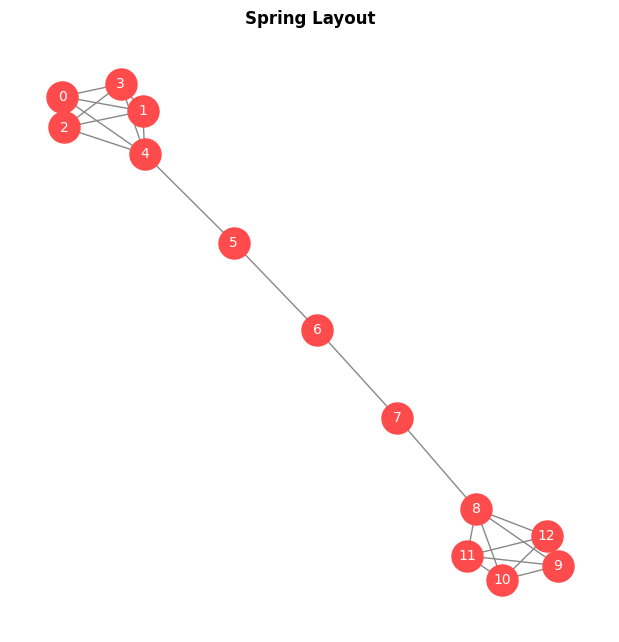

In [3]:
# 计算布局
pos = nx.spring_layout(G_barbell, seed=42)

# 绘图
plot_graph(G_barbell, pos, "Spring Layout")

## 2. Circular Layout (圆形布局)

将所有节点排列在一个圆周上。

* **适用场景**：查看连接密度，或者当节点地位平等时（如 P2P 网络）。
* **特点**：最容易看清边的分布情况（是否密集），但无法体现图的聚类结构。

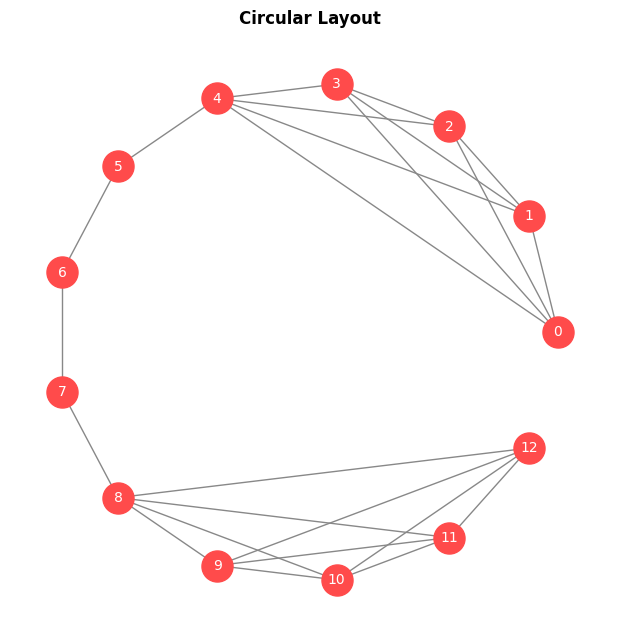

In [4]:
pos = nx.circular_layout(G_barbell)
plot_graph(G_barbell, pos, "Circular Layout")

## 3. Kamada-Kawai Layout

基于“图论距离”（最短路径距离）的力导向布局。试图使节点在绘图中的几何距离与它们在图中的理论距离成正比。

* **适用场景**：需要高质量的全局结构展示。
* **特点**：通常比 Spring 更美观，区分不同分支，但计算成本较高。

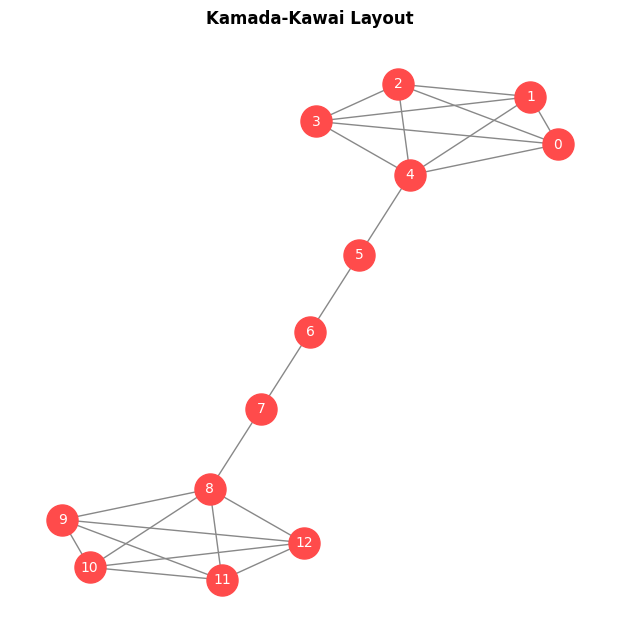

In [5]:
pos = nx.kamada_kawai_layout(G_barbell)
plot_graph(G_barbell, pos, "Kamada-Kawai Layout")

## 4. Shell Layout (壳层布局)

将节点放置在同心圆（壳）上。需要指定哪些节点在哪个壳层。

* **适用场景**：当图具有层级结构，或者想突出显示核心节点时。
* **特点**：需要手动指定 `nlist` 定义壳层。

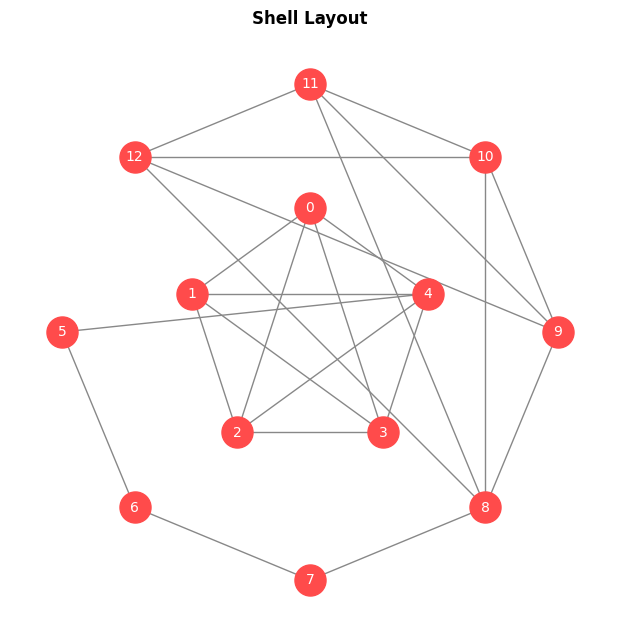

In [6]:
# 手动指定壳层：前5个节点（左铃）放在第一层，其余放在第二层
shells = [list(range(5)), list(range(5, len(G_barbell)))]

pos = nx.shell_layout(G_barbell, nlist=shells)
plot_graph(G_barbell, pos, "Shell Layout")

## 5. Random Layout (随机布局)

将节点随机放置在单位正方形内。

* **适用场景**：几乎不用于最终展示。通常用于算法测试或作为力导向算法的“初始状态”。
* **特点**：杂乱无章，没有结构信息。

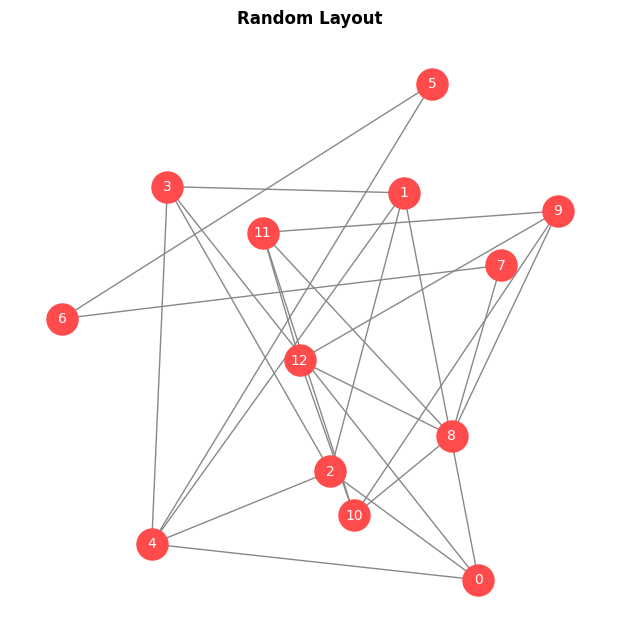

In [7]:
pos = nx.random_layout(G_barbell, seed=10)
plot_graph(G_barbell, pos, "Random Layout")

## 6. Spectral Layout (谱布局)

利用图拉普拉斯矩阵的特征向量来确定节点坐标。

* **适用场景**：识别图的对称性、特殊的几何结构或简单的聚类。
* **特点**：计算速度快（基于线性代数），但有时会导致节点重叠成一条线。

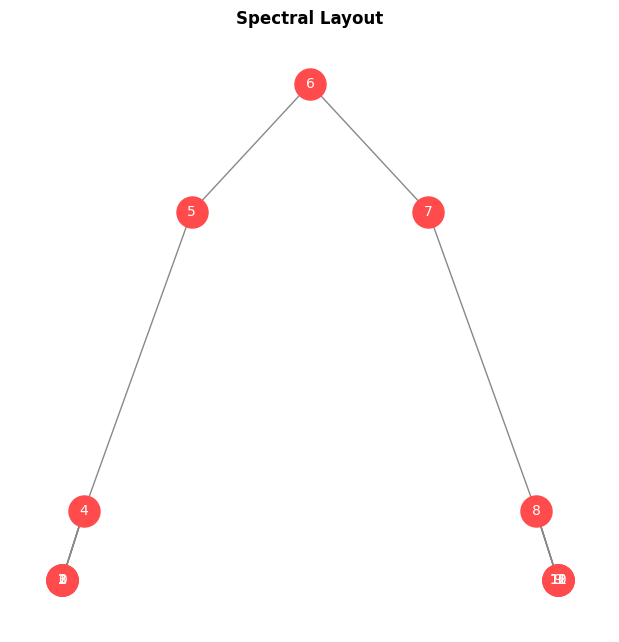

In [8]:
pos = nx.spectral_layout(G_barbell)
plot_graph(G_barbell, pos, "Spectral Layout")

## 7. Spiral Layout (螺旋布局)

将节点按照某种线性顺序排列成螺旋状。

* **适用场景**：节点具有时间序列属性，或者具有线性的 ID 增长关系。
* **特点**：视觉效果独特，能展示长链条结构。

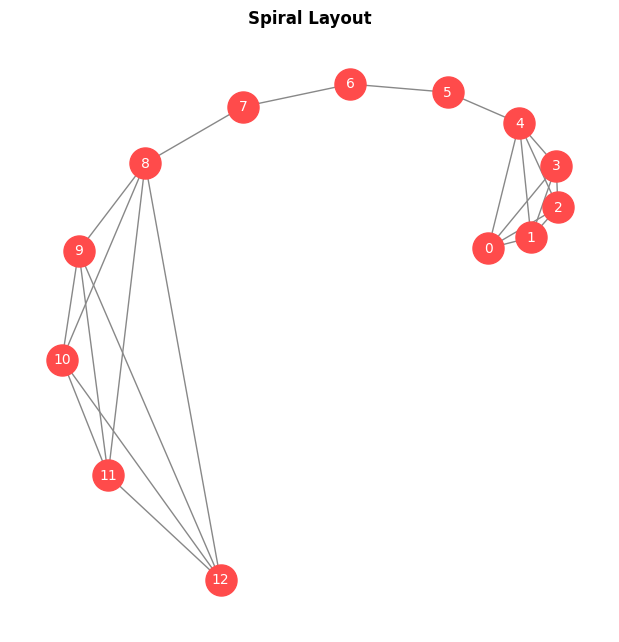

In [9]:
pos = nx.spiral_layout(G_barbell)
plot_graph(G_barbell, pos, "Spiral Layout")

## 8. Multipartite Layout (分层布局)

将节点分层排列（通常是垂直或水平的直线层）。

* **适用场景**：流程图、神经网络架构、或具有明确分级关系的数据。
* **特点**：需要为节点设置 `subset` 属性来分配层级。

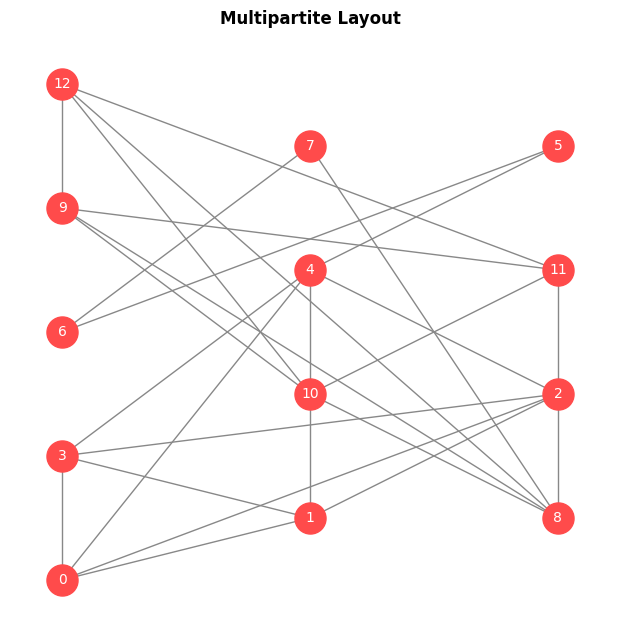

In [10]:
# 1. 为节点添加 'subset' 属性（这里简单地使用模3取余）
for i, n in enumerate(G_barbell.nodes):
    G_barbell.nodes[n]['subset'] = i % 3

# 2. 使用 subset_key 指定层级属性
pos = nx.multipartite_layout(G_barbell, subset_key='subset')
plot_graph(G_barbell, pos, "Multipartite Layout")

## 9. Planar Layout (平面布局)

尝试在不让边交叉的情况下绘制图。

* **适用场景**：仅适用于 **平面图** (Planar Graph)。如果图包含不可避免的交叉边，该函数会报错。
* **特点**：整洁，适合展示拓扑结构。

**注意**：由于 Barbell Graph 不是平面图（两端的 K5 完全图包含交叉），这里我们**切换使用一个小型的迷宫图**来演示此布局。

Switched to Sedgewick Maze Graph for Planar Layout demo.


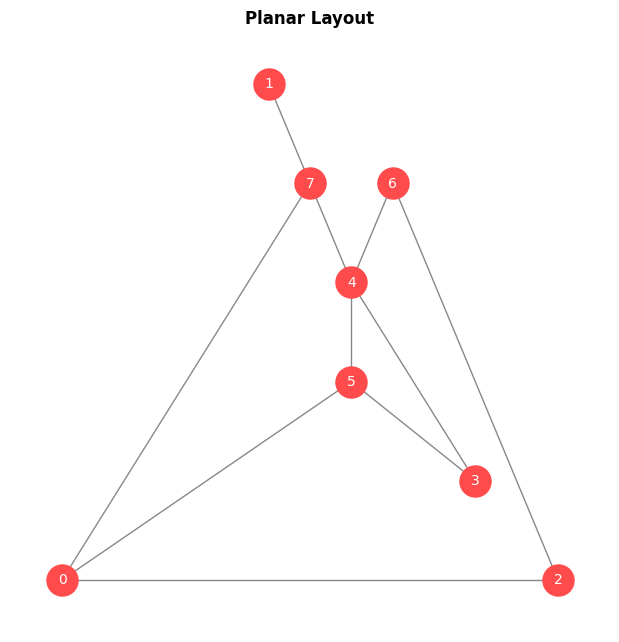

In [11]:
# 切换测试图：小型迷宫图 (Sedgewick Maze Graph)
G_maze = nx.sedgewick_maze_graph()
print("Switched to Sedgewick Maze Graph for Planar Layout demo.")

pos = nx.planar_layout(G_maze)
plot_graph(G_maze, pos, "Planar Layout")